In [2]:
!pip install -q torch torchvision segmentation-models-pytorch
!pip install -q albumentations opencv-python matplotlib scikit-learn
print("Packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00
Packages installed!


In [3]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "samboateng190",
    "key": "KGAT_830317c6928b5d0cc971dc004e6527c8"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print(" Kaggle configured!")

!kaggle datasets list --search "skin lesion segmentation" 2>&1 | head -5

 Kaggle configured!
ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
fatemehmehrparvar/skin-cancer-detection                              Skin Cancer Detection                                 32011839  2024-02-16 08:18:57.660000           1025         47  0.75             
tschandl/ham10000-lesion-segmentations                               HAM10000 Lesion Segmentations                         10766207  2020-07-02 21:20:22.710000           2988         35  0.875            
nightfury007/ham10000-isic2018-raw                                   HAM10000_ISIC2018_RAW                               3203952535  2025-01-01 15:11:10.847000 

In [4]:
# Download HAM10000 segmentation masks
!kaggle datasets download -d tschandl/ham10000-lesion-segmentations
!unzip -q ham10000-lesion-segmentations.zip -d seg_data
print(" Segmentation masks downloaded!")
!ls seg_data/

Dataset URL: https://www.kaggle.com/datasets/tschandl/ham10000-lesion-segmentations
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 10.3M/10.3M [00:00<00:00, 41.8MB/s]

 Segmentation masks downloaded!
HAM10000_segmentations_lesion_tschandl


In [5]:
# Download HAM10000 original images (we need both images + masks)
!kaggle datasets download -d surajghuwalewala/ham1000-segmentation-and-classification
!unzip -q ham1000-segmentation-and-classification.zip -d img_data
print(" Images downloaded!")
!ls img_data/

Dataset URL: https://www.kaggle.com/datasets/surajghuwalewala/ham1000-segmentation-and-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 2.59G/2.59G [00:16<00:00, 172MB/s]

 Images downloaded!
GroundTruth.csv  images  masks


Total images : 10017
Total masks  : 10015

Sample image name : ATTRIBUTION.txt
Sample mask name  : ISIC_0024306_segmentation.png

Matched pairs: 10015


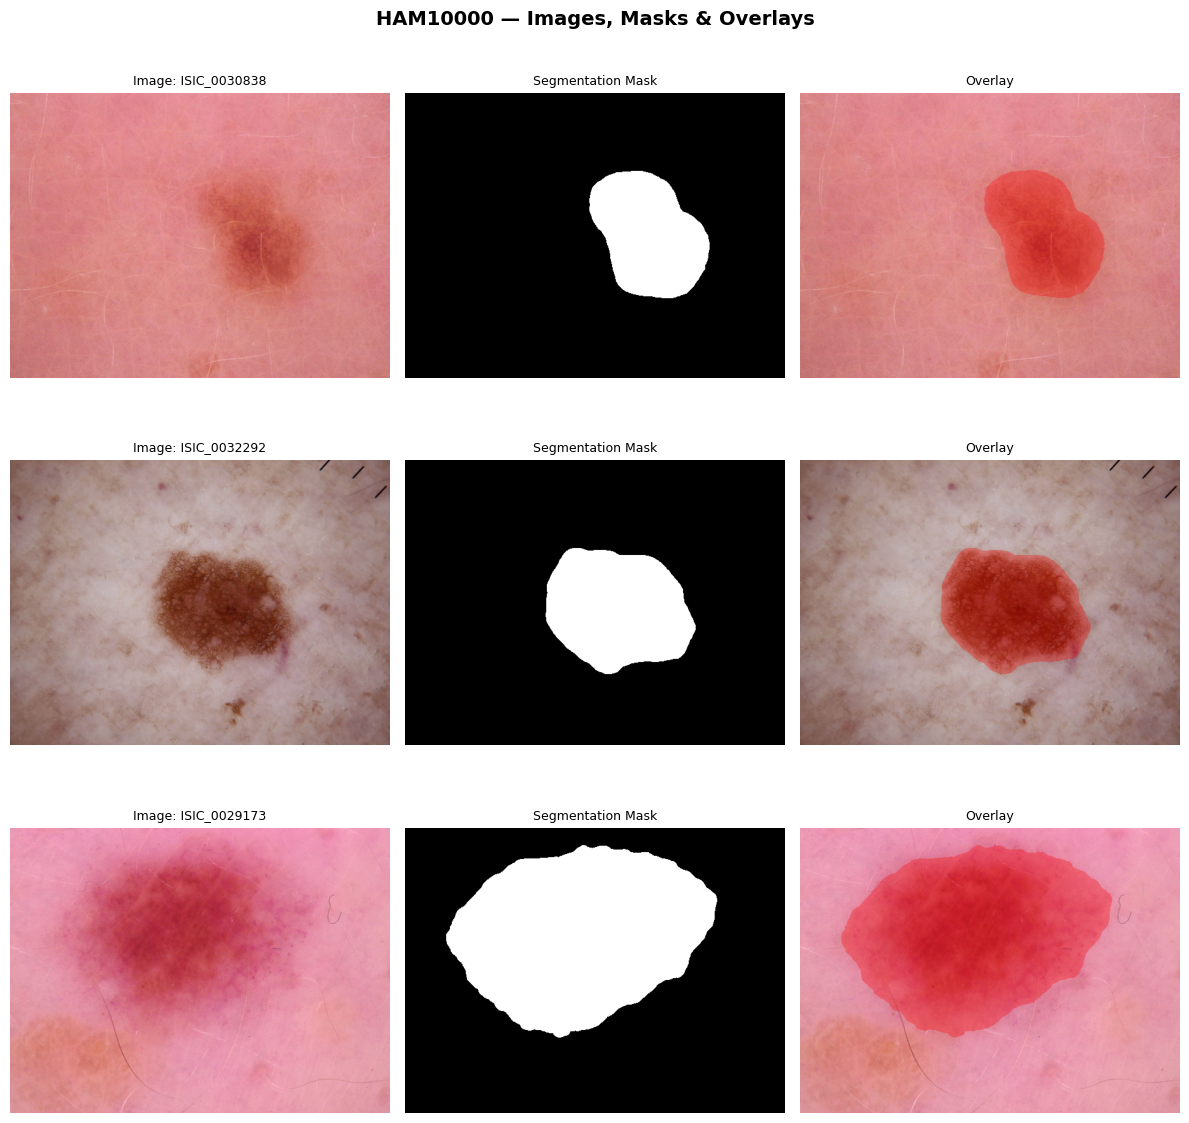

 Sample pairs visualized!


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Check data
img_dir  = 'img_data/images'
mask_dir = 'seg_data/HAM10000_segmentations_lesion_tschandl'

# List files
images = sorted(os.listdir(img_dir))
masks  = sorted(os.listdir(mask_dir))

print(f"Total images : {len(images)}")
print(f"Total masks  : {len(masks)}")
print(f"\nSample image name : {images[0]}")
print(f"Sample mask name  : {masks[0]}")

# Find matching pairs
img_ids  = set([f.replace('.jpg', '') for f in images])
mask_ids = set([f.replace('_segmentation.png', '') for f in masks])

matched = img_ids.intersection(mask_ids)
print(f"\nMatched pairs: {len(matched)}")

#Visualize sample pairs
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
sample_ids = list(matched)[:3]

for i, img_id in enumerate(sample_ids):
    img  = Image.open(os.path.join(img_dir, img_id + '.jpg')).convert('RGB')
    mask = Image.open(os.path.join(mask_dir, img_id + '_segmentation.png')).convert('L')

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image: {img_id[:15]}", fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Segmentation Mask", fontsize=9)
    axes[i, 1].axis('off')

    # Overlay
    img_np   = np.array(img)
    mask_np  = np.array(mask)
    overlay  = img_np.copy()
    overlay[mask_np > 127] = [255, 0, 0]
    blended  = (0.7 * img_np + 0.3 * overlay).astype(np.uint8)

    axes[i, 2].imshow(blended)
    axes[i, 2].set_title("Overlay", fontsize=9)
    axes[i, 2].axis('off')

plt.suptitle('HAM10000 — Images, Masks & Overlays', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sample pairs visualized!")

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import cv2
import numpy as np


# Build paired list of (image_path, mask_path) from both directories

paired_data = []
for mask_file in sorted(os.listdir(mask_dir)):
    if mask_file.endswith('_segmentation.png'):
        img_id    = mask_file.replace('_segmentation.png', '')
        img_path  = os.path.join(img_dir,  img_id + '.jpg')
        mask_path = os.path.join(mask_dir, mask_file)
        if os.path.exists(img_path):
            paired_data.append((img_path, mask_path))

print(f"Total paired samples : {len(paired_data)}")


# Split into train / validation / test sets (80 / 10 / 10)

train_data, temp_data = train_test_split(paired_data, test_size=0.2, random_state=42)
val_data,   test_data = train_test_split(temp_data,   test_size=0.5, random_state=42)

print(f"Train samples : {len(train_data)}")
print(f"Val samples   : {len(val_data)}")
print(f"Test samples  : {len(test_data)}")


# Image size — U-Net requires input divisible by 32

IMG_SIZE = 256


# Augmentation pipelines
# Training: spatial + color augmentations for regularisation
# Validation/Test: resize and normalise only

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Custom Dataset
# Returns image tensor (3, H, W) and binary mask tensor (1, H, W)

class SegmentationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # Load image in RGB and mask in grayscale
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Binarise mask: lesion pixels = 1, background = 0
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image     = augmented['image']
            mask      = augmented['mask'].unsqueeze(0)  # Add channel dim -> (1, H, W)

        return image, mask

# DataLoaders

BATCH_SIZE = 16

train_dataset = SegmentationDataset(train_data, train_transform)
val_dataset   = SegmentationDataset(val_data,   val_transform)
test_dataset  = SegmentationDataset(test_data,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Verify a single batch
images, masks = next(iter(train_loader))
print(f"\nImage batch shape : {images.shape}")
print(f"Mask batch shape  : {masks.shape}")

Total paired samples : 10015
Train samples : 8012
Val samples   : 1001
Test samples  : 1002
DataLoaders ready
Train batches : 501
Val batches   : 63
Test batches  : 63

Image batch shape : torch.Size([16, 3, 256, 256])
Mask batch shape  : torch.Size([16, 1, 256, 256])


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Double conv block used in both encoder and decoder paths
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# Encoder block: conv then pool, returns skip connection and pooled output
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(EncoderBlock, self).__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        features = self.conv(x)
        pooled   = self.pool(features)
        return features, pooled


# Decoder block: upsample then concatenate skip connection then conv
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv     = ConvBlock(out_channels * 2, out_channels)

    def forward(self, x, skip):
        x = self.upsample(x)
        # Handle size mismatch due to odd input dimensions
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


# Full U-Net: encoder -> bottleneck -> decoder -> 1x1 output conv
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder path
        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64,  128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)

        # Decoder path
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512,  256)
        self.dec2 = DecoderBlock(256,  128)
        self.dec1 = DecoderBlock(128,   64)

        # Final 1x1 conv to produce binary mask logits
        self.output_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder — collect skip connections
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder — apply skip connections
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        # Raw logits — BCEWithLogitsLoss handles sigmoid internally
        return self.output_conv(x)


# Verify architecture on device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model = UNet(in_channels=3, out_channels=1).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# Test forward pass with dummy input
dummy_input  = torch.randn(2, 3, 256, 256).to(device)
dummy_output = model(dummy_input)
print(f"\nInput shape  : {dummy_input.shape}")
print(f"Output shape : {dummy_output.shape}")
print("U-Net architecture verified")

Device : cuda
Total parameters     : 31,037,633
Trainable parameters : 31,037,633

Input shape  : torch.Size([2, 3, 256, 256])
Output shape : torch.Size([2, 1, 256, 256])
U-Net architecture verified


In [9]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau


# Dice coefficient measures overlap between predicted and ground truth masks
def dice_coefficient(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    dice         = (2.0 * intersection + smooth) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)
    return dice.mean()


# Combined loss: BCE handles class imbalance, Dice handles segmentation quality
def combined_loss(pred, target, bce_weight=0.5):
    bce          = nn.BCEWithLogitsLoss()(pred, target)
    pred_sigmoid = torch.sigmoid(pred)
    smooth       = 1e-6
    intersection = (pred_sigmoid * target).sum(dim=(2, 3))
    dice_loss    = 1 - (2.0 * intersection + smooth) / (
        pred_sigmoid.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth
    )
    return bce_weight * bce + (1 - bce_weight) * dice_loss.mean()


# Training loop for one epoch
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_dice = 0.0, 0.0

    for images, masks in loader:
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coefficient(outputs, masks).item()

    return total_loss / len(loader), total_dice / len(loader)


# Validation loop
def val_epoch(model, loader, device):
    model.eval()
    total_loss, total_dice = 0.0, 0.0

    with torch.no_grad():
        for images, masks in loader:
            images  = images.to(device)
            masks   = masks.to(device)
            outputs = model(images)
            loss    = combined_loss(outputs, masks)

            total_loss += loss.item()
            total_dice += dice_coefficient(outputs, masks).item()

    return total_loss / len(loader), total_dice / len(loader)


# Optimizer: Adam with weight decay for regularisation
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Scheduler: reduce LR when validation loss plateaus
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Training setup ready")
print(f"Optimizer : Adam (lr=1e-3, weight_decay=1e-5)")
print(f"Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)")
print(f"Loss      : BCE + Dice (50/50 weight)")

Training setup ready
Optimizer : Adam (lr=1e-3, weight_decay=1e-5)
Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)
Loss      : BCE + Dice (50/50 weight)


In [10]:
# Training loop
EPOCHS        = 20
best_val_loss = float('inf')
history       = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

print("Starting training...")
print(f"Epochs     : {EPOCHS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Device     : {device}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Dice':>12} {'Val Loss':>10} {'Val Dice':>10} {'Status':>8}")
print("-" * 65)

for epoch in range(EPOCHS):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer, device)
    val_loss,   val_dice   = val_epoch(model, val_loader, device)

    # Step scheduler based on validation loss
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_unet_model.pth")
        status = "saved"
    else:
        status = ""

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)

    print(f"{epoch+1:>6} {train_loss:>12.4f} {train_dice:>12.4f} {val_loss:>10.4f} {val_dice:>10.4f} {status:>8}")

print("-" * 65)
print(f"Training complete")
print(f"Best val loss : {best_val_loss:.4f}")

Starting training...
Epochs     : 20
Batch size : 16
Device     : cuda
 Epoch   Train Loss   Train Dice   Val Loss   Val Dice   Status
-----------------------------------------------------------------
     1       0.2967       0.7742     0.2088     0.8408    saved
     2       0.2087       0.8445     0.1742     0.8731    saved
     3       0.1883       0.8624     0.1683     0.8747    saved
     4       0.1747       0.8706     0.1576     0.8798    saved
     5       0.1650       0.8779     0.1409     0.8959    saved
     6       0.1570       0.8841     0.1458     0.8958         
     7       0.1486       0.8899     0.1267     0.9058    saved
     8       0.1479       0.8910     0.1204     0.9092    saved
     9       0.1431       0.8949     0.1250     0.9021         
    10       0.1389       0.8972     0.1394     0.8932         
    11       0.1359       0.8998     0.1283     0.9070         
    12       0.1329       0.9019     0.1203     0.9100    saved
    13       0.1299       0.904

Test Loss : 0.1211
Test Dice : 0.9115


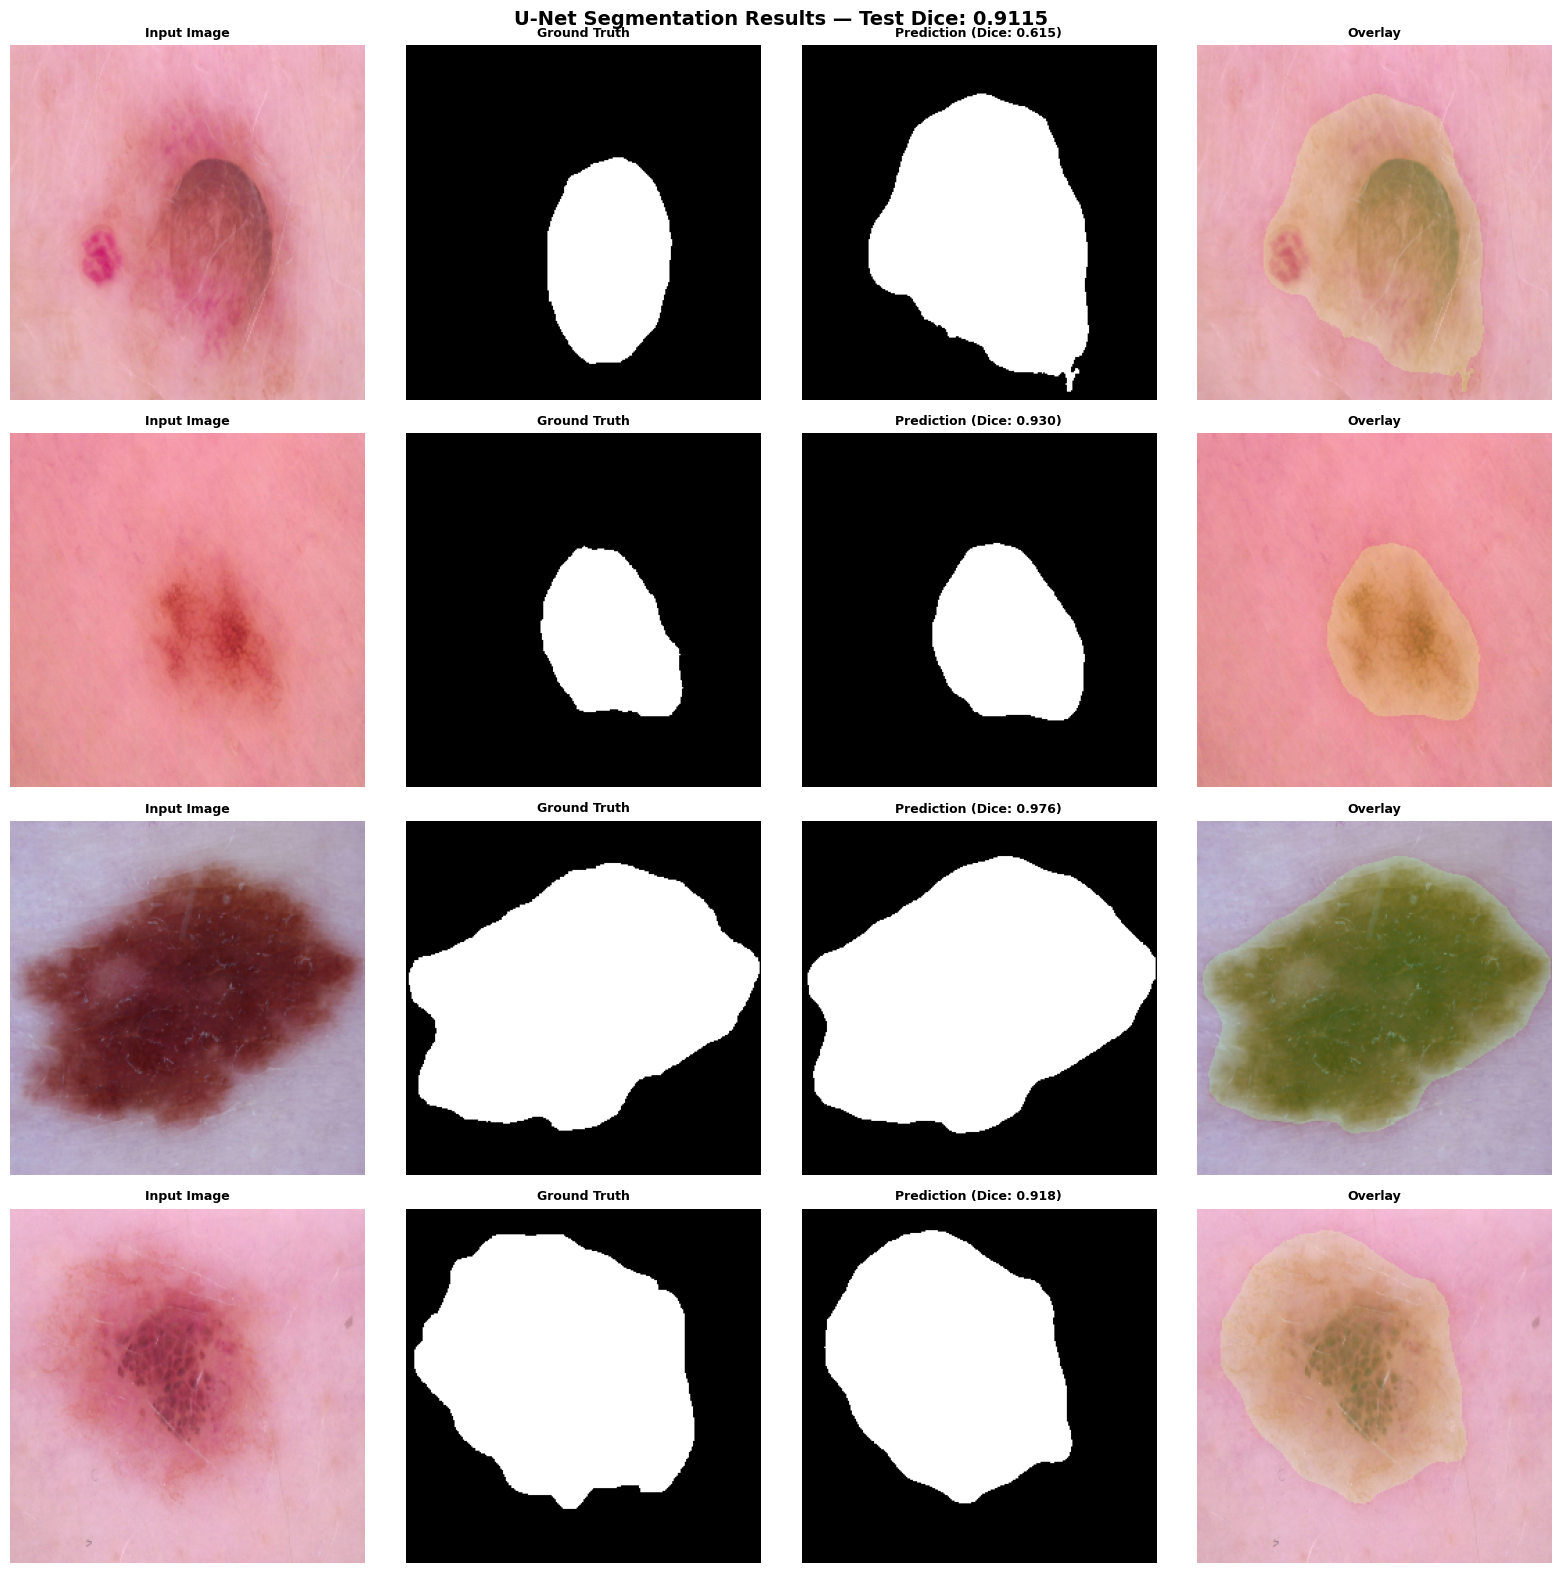

Evaluation complete


In [11]:
import matplotlib.pyplot as plt

# Load best model for evaluation
model.load_state_dict(torch.load("best_unet_model.pth"))
model.eval()

# Compute test set metrics
test_loss, test_dice = val_epoch(model, test_loader, device)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")

# Visualize predictions on sample test images
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# Get one batch from test loader
images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds   = (torch.sigmoid(outputs) > 0.5).float()

# Denormalise images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(4):
    img      = images[i].cpu() * std + mean
    img      = img.permute(1, 2, 0).numpy().clip(0, 1)
    mask     = masks[i, 0].numpy()
    pred     = preds[i, 0].cpu().numpy()

    # Compute per-sample Dice
    smooth       = 1e-6
    intersection = (pred * mask).sum()
    sample_dice  = (2.0 * intersection + smooth) / (pred.sum() + mask.sum() + smooth)

    # Original image
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input Image", fontsize=9, fontweight='bold')
    axes[i, 0].axis('off')

    # Ground truth mask
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Ground Truth", fontsize=9, fontweight='bold')
    axes[i, 1].axis('off')

    # Predicted mask
    axes[i, 2].imshow(pred, cmap='gray')
    axes[i, 2].set_title(f"Prediction (Dice: {sample_dice:.3f})", fontsize=9, fontweight='bold')
    axes[i, 2].axis('off')

    # Overlay prediction on image
    overlay         = img.copy()
    overlay[:, :, 1] = np.where(pred > 0.5, 1.0, overlay[:, :, 1])  # Green channel
    blended         = (0.7 * img + 0.3 * overlay).clip(0, 1)

    axes[i, 3].imshow(blended)
    axes[i, 3].set_title("Overlay", fontsize=9, fontweight='bold')
    axes[i, 3].axis('off')

plt.suptitle(f"U-Net Segmentation Results — Test Dice: {test_dice:.4f}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segmentation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation complete")

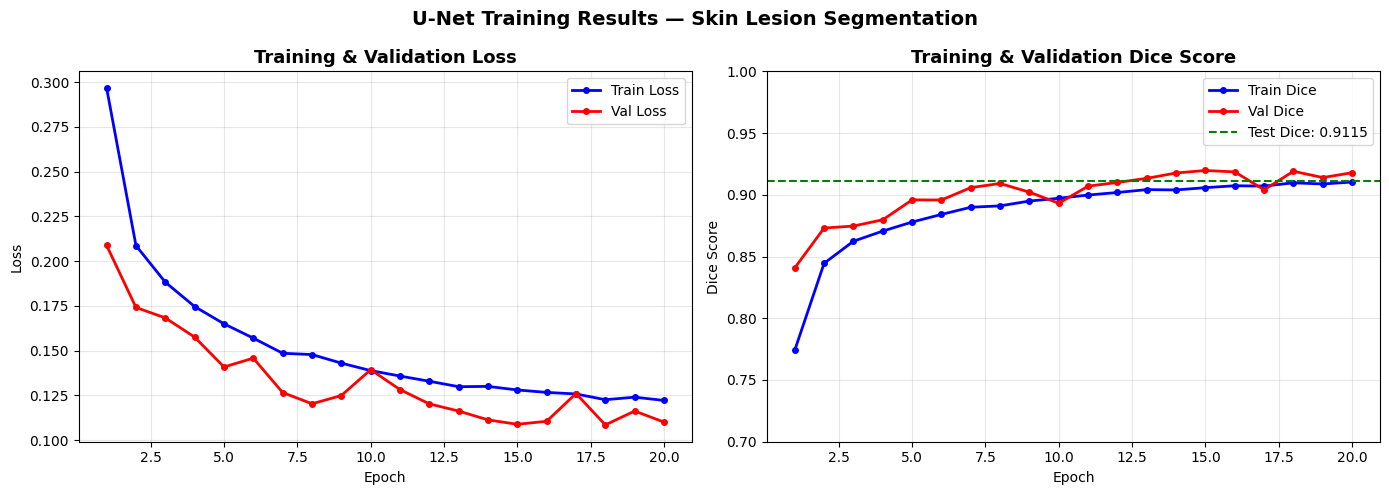

Training curves saved


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, EPOCHS + 1)

# Loss curves
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2, markersize=4)
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice curves
axes[1].plot(epochs, history['train_dice'], 'b-o', label='Train Dice', linewidth=2, markersize=4)
axes[1].plot(epochs, history['val_dice'],   'r-o', label='Val Dice',   linewidth=2, markersize=4)
axes[1].axhline(y=test_dice, color='g', linestyle='--', linewidth=1.5, label=f'Test Dice: {test_dice:.4f}')
axes[1].set_title('Training & Validation Dice Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.7, 1.0)

plt.suptitle('U-Net Training Results — Skin Lesion Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved")

In [15]:
from google.colab import files

# Download all artifacts
files.download('best_unet_model.pth')
files.download('segmentation_results.png')
files.download('training_curves.png')
print("All files downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded
